In [ ]:
### How to change config 
'''
from config import ExperimentConfig, with_overrides

cfg0 = ExperimentConfig(imagenet_path="/path/to/imagenet")

# Baseline run
cfg = cfg0  # 8-bit input, fp32 model

# Experiment: 4-bit input
cfg_q4 = with_overrides(cfg0, input_quant_bits=4)

# Experiment: fp16 model
cfg_fp16 = with_overrides(cfg0, model_dtype="fp16")

# Experiment: 2-bit input + int8 model
cfg_combo = with_overrides(cfg0, input_quant_bits=2, model_dtype="int8")

cfg = with_overrides(cfg0, model_precision="fp16", input_quant_bits=4)

'''

# Baseline FP32 – ResNet-18 on ImageNet
- Input: standard 8-bit RGB
- Precision: FP32
- Split: validation

In [10]:
import sys
sys.path.insert(0, "../src")

import torch
import torch.nn as nn
import json
from pathlib import Path

from config import ExperimentConfig, set_seed, with_overrides
from main import run_experiment
from data import get_dataloader
from plots import plot_all, plot_loss, plot_accuracy
import eval

In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())


Torch: 2.10.0+cu128
CUDA: True


In [5]:
# Configuration for baseline

IMAGENET_PATH = "/home/pf4636/imagenet2" 

cfg_base = ExperimentConfig(
    imagenet_path=IMAGENET_PATH,
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=256,
    num_workers=8,
    input_quant_bits=8,
    model_precision="fp32"
)
set_seed(cfg_base)

In [6]:
# Visualizing configurations
print(f"Config:")
print(f"  Device: {cfg_base.device}")
print(f"  Batch size: {cfg_base.batch_size}")
print(f"  Input quant bits: {cfg_base.input_quant_bits}")
print(f"  Model precision: {cfg_base.model_precision}")
print()

Config:
  Device: cuda
  Batch size: 256
  Input quant bits: 8
  Model precision: fp32



--- Running FP32 Baseline ---
EXPERIMENT CONFIGURATION
Model precision:       fp32
Input quantization:    8-bit
Batch size:            256
Num workers:           8
Device:                cuda
ImageNet path:         /home/pf4636/imagenet2
Num eval batches:      All

Loading val data...
Dataloader ready: 196 batches

Loading model...
Model loaded: ResNet18
Evaluating on 196 batches...
  Batch [10/196] Top-1: 78.52% | Top-5: 93.16% | Infer: 110.85 ms/batch
  Batch [20/196] Top-1: 76.66% | Top-5: 92.68% | Infer: 103.00 ms/batch
  Batch [30/196] Top-1: 77.93% | Top-5: 92.85% | Infer: 100.39 ms/batch
  Batch [40/196] Top-1: 76.23% | Top-5: 92.95% | Infer: 99.08 ms/batch
  Batch [50/196] Top-1: 75.80% | Top-5: 93.20% | Infer: 98.30 ms/batch
  Batch [60/196] Top-1: 75.70% | Top-5: 93.38% | Infer: 97.79 ms/batch
  Batch [70/196] Top-1: 76.21% | Top-5: 93.53% | Infer: 97.41 ms/batch
  Batch [80/196] Top-1: 76.14% | Top-5: 93.37% | Infer: 97.15 ms/batch
  Batch [90/196] Top-1: 74.97% | Top-5: 92.

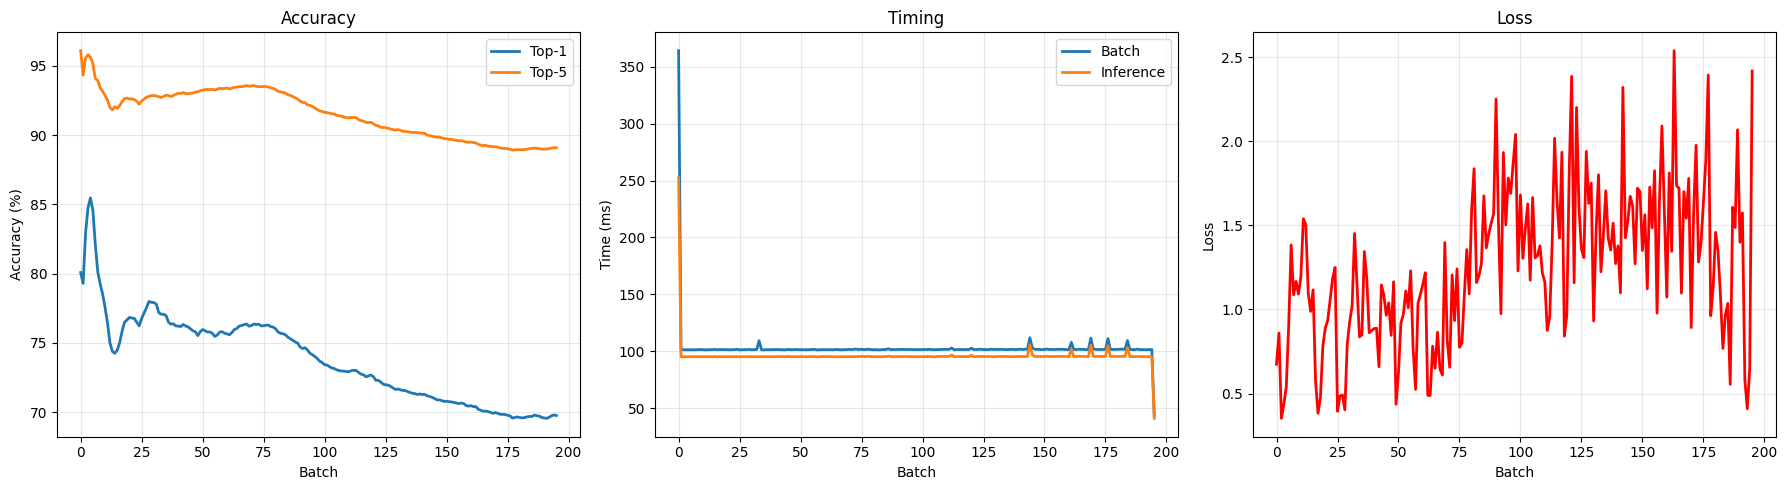

In [8]:
print("--- Running FP32 Baseline ---")
results_fp32, tracker_fp32 = run_experiment(
    cfg_base, 
    split="val", 
    save_results_flag=True
)

print("Displaying FP32 Baseline Plots:")
plot_all(tracker_fp32, save_dir="../results/fp32_baseline")


--- Running FP16 Baseline ---
EXPERIMENT CONFIGURATION
Model precision:       fp16
Input quantization:    8-bit
Batch size:            256
Num workers:           8
Device:                cuda
ImageNet path:         /home/pf4636/imagenet2
Num eval batches:      All

Loading val data...
Dataloader ready: 196 batches

Loading model...
Model loaded: ResNet18
Evaluating on 196 batches...
  Batch [10/196] Top-1: 78.55% | Top-5: 93.16% | Infer: 73.56 ms/batch
  Batch [20/196] Top-1: 76.72% | Top-5: 92.70% | Infer: 63.82 ms/batch
  Batch [30/196] Top-1: 77.97% | Top-5: 92.88% | Infer: 60.58 ms/batch
  Batch [40/196] Top-1: 76.27% | Top-5: 92.97% | Infer: 59.11 ms/batch
  Batch [50/196] Top-1: 75.83% | Top-5: 93.22% | Infer: 58.45 ms/batch
  Batch [60/196] Top-1: 75.72% | Top-5: 93.39% | Infer: 57.73 ms/batch
  Batch [70/196] Top-1: 76.22% | Top-5: 93.54% | Infer: 57.21 ms/batch
  Batch [80/196] Top-1: 76.15% | Top-5: 93.39% | Infer: 56.82 ms/batch
  Batch [90/196] Top-1: 75.00% | Top-5: 92.61

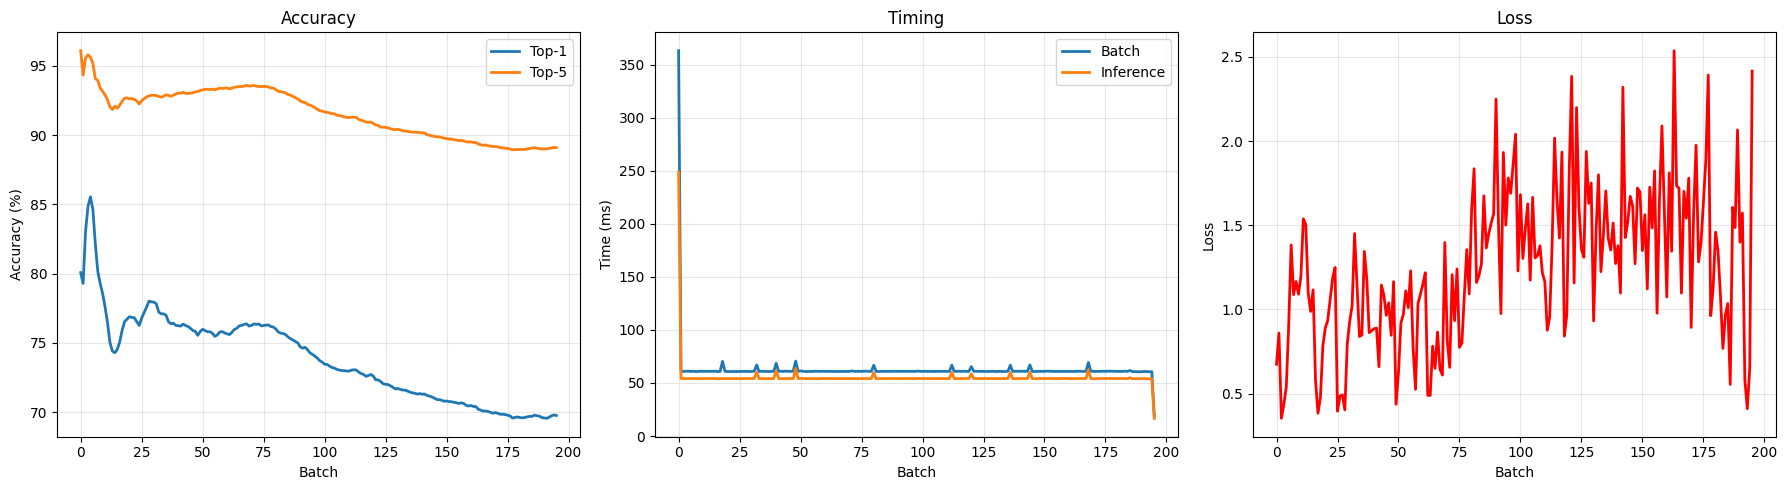

In [11]:
if torch.cuda.is_available():
    print("\n--- Running FP16 Baseline ---")
    cfg_fp16 = with_overrides(cfg_base, model_precision="fp16")
    
    results_fp16, tracker_fp16 = run_experiment(
        cfg_fp16, 
        split="val", 
        save_results_flag=True
    )
    
    print("Displaying FP16 Baseline Plots:")
    plot_all(tracker_fp16, save_dir="../results/fp16_baseline")
else:
    print("Skipping FP16 (CUDA not available)")